* 为什么要学 KD
  * 必要;
    * GPT 时代
    * 业务所需;
  * 模型结构 (分支) 和损失函数的设计，值得借鉴
* openai GPT 一骑绝尘的时代，GPT4 就是老师;
* Teacher-Student paradigm
  * 在训练中将 teacher 的知识蒸馏/transfer 到 student model 中;
    * 对于 student model 而言，就是 mimic (模仿) 的过程;
  * teacher: larger, slower, better-performing
  * student: smaller
* 2006年提出来，是在 ensemble models (集成模型) 的语境下提出来的;
  * 2015年，引入到深度学习;
* 本节的重点是知识蒸馏的 模型架构 (loss Function) 及 Pipeline;

# 知识蒸馏理论笔记 (Knowledge Distillation Theory Notes)

* **理论方面 (Theoretical Aspects)**
  * Student model 学的不是一个 single value (one-hot representation), 而是 teacher model 预测的概率分布 (dense feature representation);
  * 关于多分类问题的输出:
    * ground truth: hard target, one-hot encoding
    * Teacher predict output: softmax ($T = 1$)
      * soften probabilities ($T > 1$)

---

* **假如对于一个有监督的分类问题，对于样本 $x$,**
  * 对于 Teacher model, 其 output (logits) 为 $z(x) = [z_1(x), z_2(x), \cdots, z_N(x)]$
    * 将其进一步通过 softmax (with temperature) 转化为概率化的输出:

$$p_i(x) = \frac{\exp\left(\frac{z_i(x)}{T}\right)}{\sum_j \exp\left(\frac{z_j(x)}{T}\right)}$$

  * 对于 Student model, 其预测的概率分布为 $q_i(x)$
  * 此时使用 KL-divergence (KL-散度) 来度量两个概率分布的距离 (或者叫差异)

$$D_{KL}(p, q) = \sum_i p_i(x) \log \frac{p_i(x)}{q_i(x)}$$

$$L_{KD} = T^2 D_{KL}$$

---

* **通过 KL-divergence, 也度量了当 Student model (用 $q_i(x)$) 来逼近/近似 Teacher model (用 $p_i(x)$) 的信息损失;**

$$
\begin{aligned}
L_{student} &= \alpha L_{CE} + (1 - \alpha) L_{KD} \\
&= \alpha L_{CE} + (1 - \alpha) T^2 D_{KL}
\end{aligned}
$$

##  kd on pretraining

* BERT 开启了一个范式：pretraining + downstream tasks
* 同样地对 pretraining model （比如 BERT）进行 distill 得到 DistilBert
  * [https://arxiv.org/abs/1910.01108 (DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter)](https://arxiv.org/abs/1910.01108)
    * [https://medium.com/huggingface/distilbert-8cf3380435b5](https://medium.com/huggingface/distilbert-8cf3380435b5)
  * $L_{cos} = 1 - \cos(h_s, h_t)$ 不只是对齐输出，还对齐 (align) direction of hidden state vectors (representation space)

$$
\begin{aligned}
L_{distil-bert} &= \alpha L_{mlm} + \beta L_{KD} + \gamma L_{cos} \\
&= \alpha L_{mlm} + \beta L_{KD} + \gamma(1 - \cos(h_s, h_t))
\end{aligned}
$$

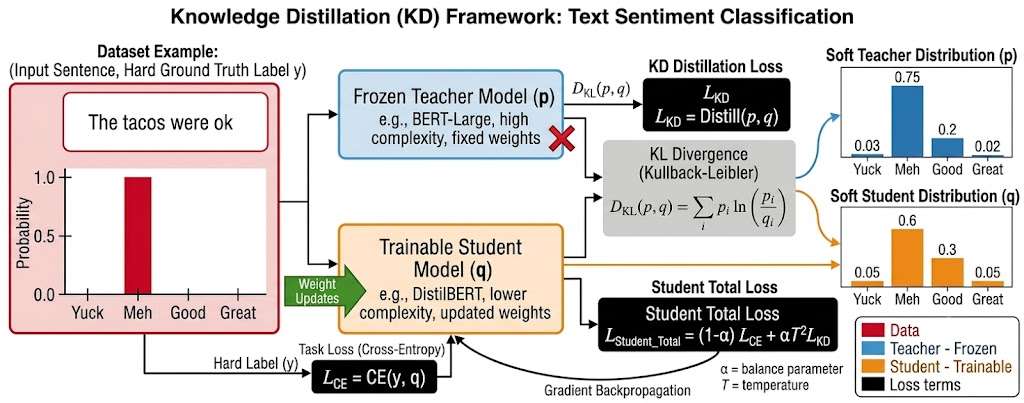

In [1]:
from transformers import TrainingArguments, Trainer
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import wandb

In [2]:
class DistillTrainingArguments(TrainingArguments):
    # TrainingArguments: @dataclass
    # 增加两个 KD 所需的参数参数
    def __init__(self, *args, alpha=0.5, temperature=2., **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.temperature = temperature

In [25]:
class DistillTrainer(Trainer):

    def __init__(self, *args, teacher_model=None, **kwargs):
        # 增加 teacher_model 参数
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model.to(self.args.device) if teacher_model is not None else None

    # 重写 trainer 中核心方法
    # forward 计算损失
    def compute_loss(self, model, inputs, return_outputs=False,**kwargs):
        s_output = model(**inputs)
        s_ce = s_output.loss
        s_logits = s_output.logits

        with torch.no_grad():
            t_output = self.teacher_model(**inputs)
            t_logits = t_output.logits

        loss_kl_fct = nn.KLDivLoss(reduction='batchmean')
        loss_kd = self.args.temperature**2 * loss_kl_fct(F.log_softmax(s_logits/self.args.temperature, dim=-1),
                                                         F.softmax(t_logits/self.args.temperature, dim=-1))

        loss = self.args.alpha * s_ce + (1-self.args.alpha) * loss_kd
        return (loss, s_output) if return_outputs else loss

## pipeline

### dataset

In [4]:
!pip install -U transformers datasets huggingface_hub evaluate

In [5]:
from datasets import load_dataset
clinc = load_dataset("clinc/clinc_oos", "plus")
print(clinc)

README.md:   0%|          | 0.00/24.0k [00:00<?, ?B/s]

plus/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  312kB            

plus/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plus/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 77.8kB            

plus/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plus/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})


In [6]:
clinc

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})

In [7]:
clinc['train'][:10]

{'text': ['what expression would i use to say i love you if i were an italian',
  "can you tell me how to say 'i do not speak much spanish', in spanish",
  "what is the equivalent of, 'life is good' in french",
  "tell me how to say, 'it is a beautiful morning' in italian",
  'if i were mongolian, how would i say that i am a tourist',
  "how do i say 'hotel' in finnish",
  "i need you to translate the sentence, 'we will be there soon' into portuguese",
  'please tell me how to ask for a taxi in french',
  "can you tell me how i would say, 'more bread please' in french",
  "what is the correct way to say 'i am a visitor' in french"],
 'intent': [61, 61, 61, 61, 61, 61, 61, 61, 61, 61]}

In [8]:
intents = clinc['train'].features['intent']
num_labels = intents.num_classes
num_labels

151

student model

In [9]:
from transformers import AutoConfig, AutoTokenizer
from transformers import AutoModelForSequenceClassification

In [10]:
s_ckpt = 'distilbert-base-uncased'
s_tokenizer = AutoTokenizer.from_pretrained(s_ckpt)

t_ckpt = 'transformersbook/bert-base-uncased-finetuned-clinc'
t_model = AutoModelForSequenceClassification.from_pretrained(t_ckpt, num_labels=num_labels)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/8.18k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [11]:
clinc_enc = clinc.map(lambda batch: s_tokenizer(batch['text'], truncation=True),
                      batched=True,
                      remove_columns=["text"]
                      )
clinc_enc = clinc_enc.rename_columns({'intent': 'labels'})
clinc_enc

Map:   0%|          | 0/15250 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5500
    })
})

In [13]:
batch_size = 64
s_training_args = DistillTrainingArguments(output_dir='distilbert-base-uncased-ft-clinc',
                                           eval_strategy='epoch', num_train_epochs=5,
                                           learning_rate=3e-4,
                                           per_device_train_batch_size=batch_size,
                                           per_device_eval_batch_size=batch_size,
                                           alpha=0.5, weight_decay=0.01,
                                           logging_strategy='epoch',
                                           push_to_hub=False)
s_config = AutoConfig.from_pretrained(s_ckpt, num_labels=num_labels,
                                      id2label=t_model.config.id2label, label2id=t_model.config.label2id)
# s_config

In [20]:
def student_init():
    return AutoModelForSequenceClassification.from_pretrained(s_ckpt, config=s_config)

## trainer.train

In [15]:
# from datasets import load_metric
# accuracy_score = load_metric('accuracy')
# SequenceClassification
import evaluate
accuracy_score = evaluate.load('accuracy')

In [16]:
# trainer 重要的回调函数，非成员函数
def compute_metrics(pred):
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=-1)
    return accuracy_score.compute(references=labels, predictions=predictions)

In [26]:
distill_trainer = DistillTrainer(model_init=student_init, teacher_model=t_model, args=s_training_args,
                                 train_dataset=clinc_enc['train'], eval_dataset=clinc_enc['validation'],
                                 compute_metrics=compute_metrics, processing_class=s_tokenizer)
distill_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.017781,0.396465,0.910968
2,0.282970,0.347625,0.927742
3,0.214276,0.293556,0.944194
4,0.188950,0.280025,0.947097
5,0.180370,0.280079,0.946774


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1195, training_loss=0.3768693357331982, metrics={'train_runtime': 306.0261, 'train_samples_per_second': 249.162, 'train_steps_per_second': 3.905, 'total_flos': 427022126020140.0, 'train_loss': 0.3768693357331982, 'epoch': 5.0})

In [27]:
import math
math.ceil(15250/(64*2)) * 5

600

使用

In [28]:
from transformers import pipeline

# ft_ckpt = 'lanchunhui/distilbert-base-uncased-ft-clinc'
# distill_trainer.push_to_hub('finetune completed!')

pipe = pipeline('text-classification', model='./distilbert-base-uncased-ft-clinc/')

ValueError: Unrecognized model in ./distilbert-base-uncased-ft-clinc/. Should have a `model_type` key in its config.json.